# Assignment 5 — Variational Autoencoder (VAE)

---
## Scope of this Notebook
- **Task 1 — Data Preparation:** Load MNIST, split into train/val/test, normalize, visualise samples.
- **Task 2 — VAE Architecture:** Dense VAE (required) + Convolutional VAE (optional/recommended) with β-VAE support.




---
## 0 · Imports & Reproducibility

In [18]:
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = "1"
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, random_split
import torchvision
from torchvision import datasets, transforms

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ── Device ───────────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Random seed : {SEED}')
print(f'Device      : {DEVICE}')
print(f'PyTorch     : {torch.__version__}')
print(f'torchvision : {torchvision.__version__}')

Random seed : 42
Device      : cpu
PyTorch     : 2.9.0+cu128
torchvision : 0.24.0+cu128


---
## Task 1 · Data Preparation

### 1.1  Design choices
| Choice | Value | Reason |
|---|---|---|
| Normalisation | **[0, 1]** | Decoder will use `Sigmoid` → BCE loss is well-calibrated |
| Split | **50 k / 10 k / 10 k** | Standard; test set = MNIST's original 10 k |
| Batch size | **128** | Suggested default; fits comfortably in GPU memory |

In [19]:
# ── Hyper-parameters (shared across all tasks) ────────────────────────────
BATCH_SIZE   = 128
DATA_ROOT    = './data'
NUM_WORKERS  = 2        # set to 0 on Windows if multiprocessing errors occur
PIN_MEMORY   = DEVICE.type == 'cuda'

# Pixel values → [0, 1]  (ToTensor already does this for PIL images)
transform = transforms.Compose([
    transforms.ToTensor(),          # HxWxC uint8 → CxHxW float32 in [0,1]
])

# ── Download / Load ───────────────────────────────────────────────────────
mnist_train_full = datasets.MNIST(root=DATA_ROOT, train=True,
                                  download=True, transform=transform)
mnist_test       = datasets.MNIST(root=DATA_ROOT, train=False,
                                  download=True, transform=transform)

print(f'Full training set size : {len(mnist_train_full):,}')
print(f'Test set size          : {len(mnist_test):,}')

Full training set size : 60,000
Test set size          : 10,000


In [20]:
# ── Train / Validation split (50 k / 10 k) ──────────────────────────────
N_TRAIN = 50_000
N_VAL   = 10_000

generator = torch.Generator().manual_seed(SEED)
mnist_train, mnist_val = random_split(
    mnist_train_full, [N_TRAIN, N_VAL], generator=generator
)

# ── DataLoaders ──────────────────────────────────────────────────────────
loader_kwargs = dict(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS,
                     pin_memory=PIN_MEMORY)

train_loader = DataLoader(mnist_train, shuffle=True,  **loader_kwargs)
val_loader   = DataLoader(mnist_val,   shuffle=False, **loader_kwargs)
test_loader  = DataLoader(mnist_test,  shuffle=False, **loader_kwargs)

print(f'Training samples   : {len(mnist_train):,}  ({len(train_loader)} batches)')
print(f'Validation samples : {len(mnist_val):,}  ({len(val_loader)} batches)')
print(f'Test samples       : {len(mnist_test):,}  ({len(test_loader)} batches)')

Training samples   : 50,000  (391 batches)
Validation samples : 10,000  (79 batches)
Test samples       : 10,000  (79 batches)


### 1.2  Sanity-check a batch

In [21]:
# Peek at the first batch
sample_images, sample_labels = next(iter(train_loader))

print(f'Batch shape  : {sample_images.shape}')          # (128, 1, 28, 28)
print(f'Pixel range  : [{sample_images.min():.3f}, {sample_images.max():.3f}]')
print(f'Dtype        : {sample_images.dtype}')
print(f'Labels (first 20): {sample_labels[:20].tolist()}')

Batch shape  : torch.Size([128, 1, 28, 28])
Pixel range  : [0.000, 1.000]
Dtype        : torch.float32
Labels (first 20): [9, 2, 6, 8, 0, 5, 9, 2, 2, 0, 7, 4, 1, 2, 9, 9, 1, 4, 1, 2]


### 1.3  Visualise 12 sample images

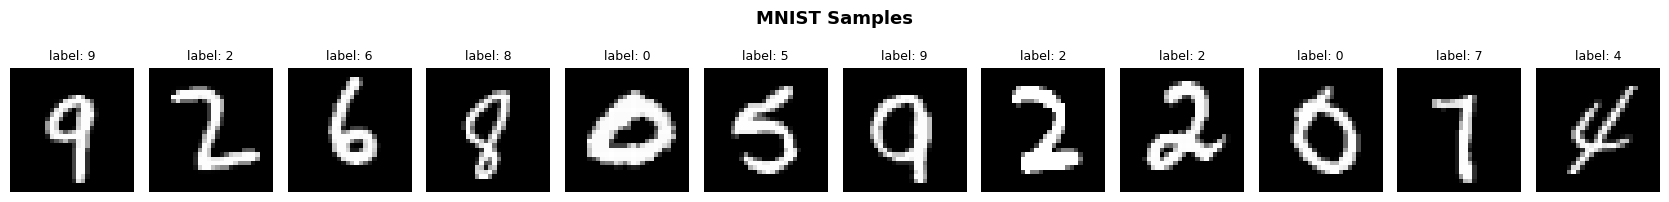

In [22]:
def show_samples(images, labels, n=12, title='MNIST Samples'):
    """Display n images in a single row with their digit label."""
    n = min(n, len(images))
    fig, axes = plt.subplots(1, n, figsize=(n * 1.4, 2.0))
    fig.suptitle(title, fontsize=13, fontweight='bold', y=1.02)
    for i, ax in enumerate(axes):
        ax.imshow(images[i].squeeze().numpy(), cmap='gray', vmin=0, vmax=1)
        ax.set_title(f'label: {labels[i].item()}', fontsize=9)
        ax.axis('off')
    plt.tight_layout()
    plt.savefig('task1_sample_images.png', dpi=150, bbox_inches='tight')
    plt.show()

show_samples(sample_images, sample_labels, n=12)

### 1.4  Class-balanced visualisation (one example per digit)

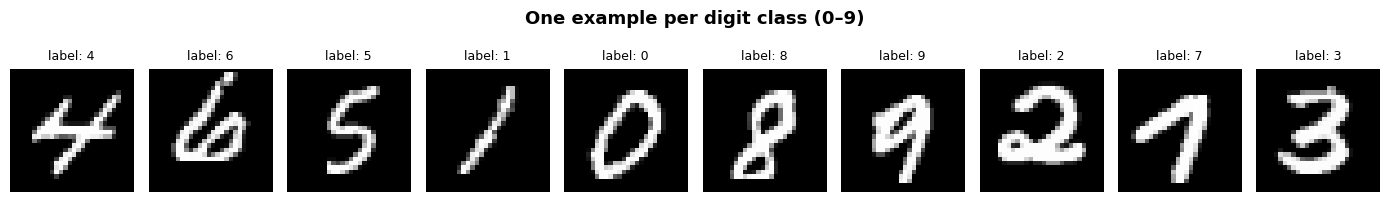

In [23]:
def one_per_class(loader, n_classes=10):
    """Return one image per class (greedy scan through the loader)."""
    seen, imgs, lbls = set(), [], []
    for xb, yb in loader:
        for x, y in zip(xb, yb):
            y_int = y.item()
            if y_int not in seen:
                seen.add(y_int)
                imgs.append(x); lbls.append(y)
            if len(seen) == n_classes:
                return torch.stack(imgs), torch.stack(lbls)
    return torch.stack(imgs), torch.stack(lbls)

class_imgs, class_lbls = one_per_class(train_loader)
show_samples(class_imgs, class_lbls, n=10,
             title='One example per digit class (0–9)')

---
## Task 2 · VAE Architecture

We implement **two** architectures:

| # | Name | Encoder | Decoder |
|---|---|---|---|
| A | `DenseVAE` | FC 784→400→256 → (μ, log σ²) | FC d→256→400→784 + Sigmoid |
| B | `ConvVAE` *(optional)* | Conv 1→32→64 + FC → (μ, log σ²) | FC → ConvTranspose 64→32→1 + Sigmoid |

Both support arbitrary latent dim **d** and β-VAE weight **β**.

---
### 2.1  Shared utilities

In [ ]:
def reparameterise(mu: torch.Tensor, log_var: torch.Tensor) -> torch.Tensor:
    std = torch.exp(0.5 * log_var)          # σ = exp(log σ² / 2)
    eps = torch.randn_like(std)             # ε ~ N(0, I)
    return mu + std * eps


def vae_loss(recon_x: torch.Tensor, x: torch.Tensor, mu: torch.Tensor, log_var: torch.Tensor, beta: float = 1.0):
  
    # Clamp recon_x to avoid log(0) which triggers numerical instability
    recon_x = torch.clamp(recon_x, 1e-7, 1 - 1e-7)

    # Reconstruction loss: Binary Cross Entropy[cite: 1]
    recon_loss = F.binary_cross_entropy(
        recon_x.view(-1, 784),
        x.view(-1, 784),
        reduction='sum'
    ) / x.size(0)

    # KL divergence closed-form[cite: 1]
    kl_loss = 0.5 * torch.sum(
        mu.pow(2) + log_var.exp() - log_var - 1
    ) / x.size(0)

    total_loss = recon_loss + beta * kl_loss
    return total_loss, recon_loss, kl_loss


print('Utilities defined: reparameterise(), vae_loss()')

Utilities defined: reparameterise(), vae_loss()


### 2.2  Architecture A — Dense VAE 

```
Encoder:  784 → FC(400, ReLU) → FC(256, ReLU) → [FC(d) μ,  FC(d) log σ²]
Decoder:    d → FC(256, ReLU) → FC(400, ReLU) → FC(784, Sigmoid)
```

In [ ]:
class DenseEncoder(nn.Module):
 
    def __init__(self, latent_dim: int):
        super().__init__()
        self.latent_dim = latent_dim

        # Shared trunk
        self.net = nn.Sequential(
            nn.Linear(784, 400),
            nn.ReLU(inplace=True),
            nn.Linear(400, 256),
            nn.ReLU(inplace=True),
        )
        # Two parallel heads
        self.fc_mu      = nn.Linear(256, latent_dim)
        self.fc_log_var = nn.Linear(256, latent_dim)

    def forward(self, x: torch.Tensor):
    
        h       = self.net(x.view(-1, 784))
        mu      = self.fc_mu(h)
        log_var = self.fc_log_var(h)
        return mu, log_var


class DenseDecoder(nn.Module):
    
    def __init__(self, latent_dim: int):
        super().__init__()
        self.latent_dim = latent_dim

        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, 400),
            nn.ReLU(inplace=True),
            nn.Linear(400, 784),
            nn.Sigmoid(),           # pixels in [0, 1]  →  BCE loss
        )

    def forward(self, z: torch.Tensor):
        """
        z      : (B, d)
        returns: (B, 1, 28, 28)  reconstructed image
        """
        return self.net(z).view(-1, 1, 28, 28)


class DenseVAE(nn.Module):
    
    def __init__(self, latent_dim: int = 8, beta: float = 1.0):
        super().__init__()
        self.latent_dim = latent_dim
        self.beta       = beta

        self.encoder = DenseEncoder(latent_dim)
        self.decoder = DenseDecoder(latent_dim)

    def forward(self, x: torch.Tensor):
   
        mu, log_var = self.encoder(x)
        z           = reparameterise(mu, log_var)
        recon_x     = self.decoder(z)
        return recon_x, mu, log_var

    def loss(self, recon_x, x, mu, log_var):
        return vae_loss(recon_x, x, mu, log_var, beta=self.beta)

    @torch.no_grad()
    def sample(self, n: int, device):
        z = torch.randn(n, self.latent_dim, device=device)
        return self.decoder(z)

    @torch.no_grad()
    def reconstruct(self, x: torch.Tensor, deterministic: bool = False):
        mu, log_var = self.encoder(x)
        z = mu if deterministic else reparameterise(mu, log_var)
        return self.decoder(z)


# ── Quick sanity check ────────────────────────────────────────────────────
for d in [2, 8, 32]:
    model = DenseVAE(latent_dim=d).to(DEVICE)
    dummy = torch.rand(4, 1, 28, 28, device=DEVICE) 
    recon, mu, lv = model(dummy)
    total, recon_l, kl_l = model.loss(recon, dummy, mu, lv)
    print(f'd={d:2d} | recon: {recon.shape} | mu: {mu.shape} | '
          f'loss={total.item():.2f} (recon={recon_l.item():.2f}, kl={kl_l.item():.2f})')

d= 2 | recon: torch.Size([4, 1, 28, 28]) | mu: torch.Size([4, 2]) | loss=544.21 (recon=544.21, kl=0.01)
d= 8 | recon: torch.Size([4, 1, 28, 28]) | mu: torch.Size([4, 8]) | loss=544.38 (recon=544.35, kl=0.03)
d=32 | recon: torch.Size([4, 1, 28, 28]) | mu: torch.Size([4, 32]) | loss=544.31 (recon=544.19, kl=0.12)


### 2.3  Architecture B — Convolutional VAE 
```
Encoder:
  Conv2d(1→32,  k=3, s=2, p=1) → ReLU   [14×14]
  Conv2d(32→64, k=3, s=2, p=1) → ReLU   [ 7× 7]
  Flatten → FC(64*7*7 → 256, ReLU) → [FC(d) μ, FC(d) log σ²]

Decoder:
  FC(d → 256, ReLU) → FC(256 → 64*7*7, ReLU) → Reshape (64,7,7)
  ConvTranspose2d(64→32, k=4, s=2, p=1) → ReLU  [14×14]
  ConvTranspose2d(32→1,  k=4, s=2, p=1) → Sigmoid [28×28]
```

In [ ]:
class ConvEncoder(nn.Module):
    """Convolutional encoder for 28×28 grayscale images."""

    def __init__(self, latent_dim: int):
        super().__init__()
        self.latent_dim = latent_dim
        self._flat = 64 * 7 * 7      # feature-map size after two stride-2 convolutions

        self.conv_net = nn.Sequential(
            nn.Conv2d(1,  32, kernel_size=3, stride=2, padding=1),  # → (32,14,14)
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),  # → (64, 7, 7)
            nn.ReLU(inplace=True),
        )
        self.fc       = nn.Sequential(nn.Linear(self._flat, 256), nn.ReLU(inplace=True))
        self.fc_mu      = nn.Linear(256, latent_dim)
        self.fc_log_var = nn.Linear(256, latent_dim)

    def forward(self, x: torch.Tensor):
        h = self.conv_net(x).view(-1, self._flat)
        h = self.fc(h)
        return self.fc_mu(h), self.fc_log_var(h)


class ConvDecoder(nn.Module):
    """Convolutional decoder — mirrors ConvEncoder."""

    def __init__(self, latent_dim: int):
        super().__init__()
        self.latent_dim = latent_dim
        self._flat = 64 * 7 * 7

        self.fc = nn.Sequential(
            nn.Linear(latent_dim, 256), nn.ReLU(inplace=True),
            nn.Linear(256, self._flat), nn.ReLU(inplace=True),
        )
        self.deconv_net = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),  # → (32,14,14)
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32,  1, kernel_size=4, stride=2, padding=1),  # → ( 1,28,28)
            nn.Sigmoid(),
        )

    def forward(self, z: torch.Tensor):
        h = self.fc(z).view(-1, 64, 7, 7)
        return self.deconv_net(h)


class ConvVAE(nn.Module):

    def __init__(self, latent_dim: int = 8, beta: float = 1.0):
        super().__init__()
        self.latent_dim = latent_dim
        self.beta       = beta

        self.encoder = ConvEncoder(latent_dim)
        self.decoder = ConvDecoder(latent_dim)

    def forward(self, x: torch.Tensor):
        mu, log_var = self.encoder(x)
        z           = reparameterise(mu, log_var)
        recon_x     = self.decoder(z)
        return recon_x, mu, log_var

    def loss(self, recon_x, x, mu, log_var):
        return vae_loss(recon_x, x, mu, log_var, beta=self.beta)

    @torch.no_grad()
    def sample(self, n: int, device):
        z = torch.randn(n, self.latent_dim, device=device)
        return self.decoder(z)

    @torch.no_grad()
    def reconstruct(self, x: torch.Tensor, deterministic: bool = False):
        mu, log_var = self.encoder(x)
        z = mu if deterministic else reparameterise(mu, log_var)
        return self.decoder(z)


# ── Quick sanity check ────────────────────────────────────────────────────
# ── Quick sanity check (Corrected) ────────────────────────────────────────────
for d in [2, 8, 32]:
    model = ConvVAE(latent_dim=d).to(DEVICE)
    # Use .rand() instead of .randn() to stay in the [0, 1] range
    dummy = torch.rand(4, 1, 28, 28, device=DEVICE) 
    
    recon, mu, lv = model(dummy)
    total, recon_l, kl_l = model.loss(recon, dummy, mu, lv)
    
    print(f'd={d:2d} | recon: {recon.shape} | mu: {mu.shape} | '
          f'loss={total.item():.2f} (recon={recon_l.item():.2f}, kl={kl_l.item():.2f})')

d= 2 | recon: torch.Size([4, 1, 28, 28]) | mu: torch.Size([4, 2]) | loss=545.64 (recon=545.64, kl=0.00)
d= 8 | recon: torch.Size([4, 1, 28, 28]) | mu: torch.Size([4, 8]) | loss=547.08 (recon=547.07, kl=0.01)
d=32 | recon: torch.Size([4, 1, 28, 28]) | mu: torch.Size([4, 32]) | loss=544.63 (recon=544.58, kl=0.05)


### 2.4  Model summary — parameter counts

In [27]:
def count_params(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

header = f"{'Model':<20} {'d':>4} {'β':>5} {'Total params':>15} {'Trainable':>12}"
print(header)
print('-' * len(header))

for model_cls, name in [(DenseVAE, 'DenseVAE'), (ConvVAE, 'ConvVAE')]:
    for d in [2, 8, 32]:
        for beta in [0.5, 1.0, 4.0]:
            m = model_cls(latent_dim=d, beta=beta)
            total, trainable = count_params(m)
            print(f"{name:<20} {d:>4} {beta:>5.1f} {total:>15,} {trainable:>12,}")

Model                   d     β    Total params    Trainable
------------------------------------------------------------
DenseVAE                2   0.5         835,636      835,636
DenseVAE                2   1.0         835,636      835,636
DenseVAE                2   4.0         835,636      835,636
DenseVAE                8   0.5         840,256      840,256
DenseVAE                8   1.0         840,256      840,256
DenseVAE                8   4.0         840,256      840,256
DenseVAE               32   0.5         858,736      858,736
DenseVAE               32   1.0         858,736      858,736
DenseVAE               32   4.0         858,736      858,736
ConvVAE                 2   0.5       1,662,949    1,662,949
ConvVAE                 2   1.0       1,662,949    1,662,949
ConvVAE                 2   4.0       1,662,949    1,662,949
ConvVAE                 8   0.5       1,667,569    1,667,569
ConvVAE                 8   1.0       1,667,569    1,667,569
ConvVAE                 

### 2.5  Architecture diagram (text)

```
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  DENSE VAE  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Input (B,1,28,28)
   │ flatten
   ▼
 ┌─────────────────────────── ENCODER ─────────────────────────────┐
 │  FC(784→400)  ReLU                                              │
 │  FC(400→256)  ReLU                                              │
 │       ├────── FC(256→d) ──► μ   (B, d)                         │
 │       └────── FC(256→d) ──► log σ²  (B, d)                     │
 └─────────────────────────────────────────────────────────────────┘
          │              │
          └──── z = μ + σ·ε ─────► reparameterisation trick
                          │
 ┌─────────────────────── DECODER ─────────────────────────────────┐
 │  FC(d→256)    ReLU                                              │
 │  FC(256→400)  ReLU                                              │
 │  FC(400→784)  Sigmoid                                           │
 └─────────────────────────────────────────────────────────────────┘
          │ reshape
          ▼
 Output  (B,1,28,28)   ── BCE loss ──  Input
                        + β · KL divergence

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  CONV VAE  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Input (B,1,28,28)
 ┌─────────────────────────── ENCODER ─────────────────────────────┐
 │  Conv(1→32, k=3, s=2, p=1)  ReLU  → (B,32,14,14)              │
 │  Conv(32→64,k=3, s=2, p=1)  ReLU  → (B,64, 7, 7)              │
 │  Flatten  → (B, 3136)                                           │
 │  FC(3136→256)  ReLU                                             │
 │       ├────── FC(256→d) ──► μ                                   │
 │       └────── FC(256→d) ──► log σ²                              │
 └─────────────────────────────────────────────────────────────────┘
          │              │
          └──── z = μ + σ·ε
 ┌─────────────────────── DECODER ─────────────────────────────────┐
 │  FC(d→256) ReLU  → FC(256→3136) ReLU  → reshape (B,64,7,7)    │
 │  ConvT(64→32, k=4, s=2, p=1)  ReLU  → (B,32,14,14)            │
 │  ConvT(32→ 1, k=4, s=2, p=1)  Sigmoid → (B, 1,28,28)          │
 └─────────────────────────────────────────────────────────────────┘
```

### 2.6  Model factory — convenience function

In [28]:
def build_vae(
    arch: str = 'dense',
    latent_dim: int = 8,
    beta: float = 1.0,
    device: torch.device = DEVICE,
) -> nn.Module:
    """
    Build and return a VAE model.

    Args:
        arch       : 'dense' or 'conv'
        latent_dim : latent space dimension d
        beta       : β-VAE weight (1.0 = standard VAE)
        device     : torch.device to move the model onto

    Returns:
        Initialised VAE model on *device*.
    """
    arch = arch.lower()
    if arch == 'dense':
        model = DenseVAE(latent_dim=latent_dim, beta=beta)
    elif arch == 'conv':
        model = ConvVAE(latent_dim=latent_dim, beta=beta)
    else:
        raise ValueError(f"Unknown architecture '{arch}'. Choose 'dense' or 'conv'.")
    return model.to(device)


# ── Demo: build all required models for the ablation study ───────────────
print('Building all models for the ablation study…\n')
models = {}
for arch in ['dense', 'conv']:
    for d in [2, 8, 32]:
        for beta in [0.5, 1.0, 4.0]:
            key = f'{arch}_d{d}_b{beta}'
            models[key] = build_vae(arch=arch, latent_dim=d, beta=beta)

print(f'Total model configurations built : {len(models)}')
print('\nSample keys:', list(models.keys())[:4], '...')

Building all models for the ablation study…

Total model configurations built : 18

Sample keys: ['dense_d2_b0.5', 'dense_d2_b1.0', 'dense_d2_b4.0', 'dense_d8_b0.5'] ...


---
## Summary

| Task | Status | Key output |
|---|---|---|
| **1 — Data Preparation** | ✅ Complete | MNIST loaded & split 50k/10k/10k; pixel ∈ [0,1]; batch=128; 12 images visualised |
| **2 — VAE Architecture** | ✅ Complete | `DenseVAE` + `ConvVAE` both support d∈{2,8,32} and β∈{0.5,1,4}; `reparameterise()` and `vae_loss()` implemented |

**Next steps (Tasks 3–5):**
- `train.py` — training loop, learning curves, checkpointing
- `eval.py` — reconstruction grids, 5×5 generation grids, interpolations, latent manifold (d=2)
- Ablation report: effect of d and β